# Turing Machine and Deep Learning

## Assignment 1: Preliminaries

This notebook is meant for you to review some mathematics to help your intuition when dealing with more complex models, and some hands on practice with `numpy` and `matplotlib` to review some programming skills. It also introduces you to some common ML lingo. This notebook must be in your GitHub directory by the deadline mentioned on Canvas.

### Handing in your Assignment

Git is an invaluable resource to researchers and developers, and thus for this course, all course material will be (additionally) shared on GitHub. Though there is a tiny bit of a learning curve, this is worth the effort. To hand in your assignment (applicable to all weeks):

1. Create a GitHub repository (this will be where you submit *all* homework assignments). Share the public link to this repository with us via
2. Create a folder called "Week 1" and copy this notebook and any other files or data that may be needed.
3. Finish the notebook and commit and push regularly. Your final commit before the deadline will be graded.


### Grading

Grading is based on effort and you can either obtain a pass or fail for the assignment.

## Question 1.1 -- Regression as minimization

Derive the closed form solution for ***a*** in a 1-dimensional linear regression as states as an optimization (minimization) problem. You may upload a handwritten scan/photograph, a screenshot of a text editor, or LaTeX notation directly.

- *Given*: $n$ input-output pairs of the form $$(x_i, y_i)$$
- *To find*: The coefficients of the line of best fit $$\hat{y_i} = a+bx_i$$
- *Loss function*: The sum of squared errors: $$f(Y, \hat{Y})=\sum_{i=0}^{n}(y_i-\hat{y}_i)^2$$
- ***b*** is found by taking partial derivates with respect to ***b*** and setting it to zero. This gives $$ b = \frac{\sum_{i=0}^{n}(x_i - \bar{x})(y_i-\bar{y})}{\sum_{i=0}^{n}(x_i - \bar{x})^2} $$
Note that in general, loss functions are the distance function *averaged over all data points in the set*. For now, you can ignore this point.

*Hint: Treat this as a regular minimization problem. Find where the partial derivates are zero of the error are with respect to the variables you wish to find.*

answer in doc file q1.1



## Question 1.2 -- Function analysis

Is there only one unique solution for $a$ and $b$? Why/why not?

*Hint: Think of the shape of the loss function, a.k.a. the 'loss landscape'.*

For the second part, the solutions do not change when using mean squared error instead of sum of squared errors, because MSE is just SSE divided by
n. Dividing by a positive constant changes only the scale of the loss, not the values of a and b that minimize it.

Would the solutions for $a$ and $b$ be different if you used mean squared error instead of sum of squared errors? Why?

For the first part, there is one unique solution for a and b because the loss function is a convex quadratic in the parameters, so it has a single global minimum. This is true provided the 𝑥𝑖 values are not all equal. If all 𝑥𝑖 are the same, then b is not uniquely identified.

## Question 2.1 -- Function generation

Write a function that takes as input a list of floats $x_i$ to and outputs a list of the form:
$$y_i=sin(x_i)+\eta_i$$
where $\eta_i$ is normally sampled noise with a small standard deviation $\epsilon$:
$$\eta_i \sim \mathcal{N}(0, \epsilon)$$

Now, to see your work, plot it!
- Sample 20 equally-spaced points from the range $x\in [0,\pi/4]$ (cf. numpy's `linspace` function).
- Set $\epsilon=0.1$
- Sample y-values from your function using the noisy formula above.
- Plot this as a scatter plot.
- For reference, plot the function $y_i=sin(x_i)$ (no noise).
- Don't forget to add labels, a legend and other information.
- Optional Tip: Set a random seed (np.random.seed) to ensure reproducability of your results.

---


Your results should look something like this:

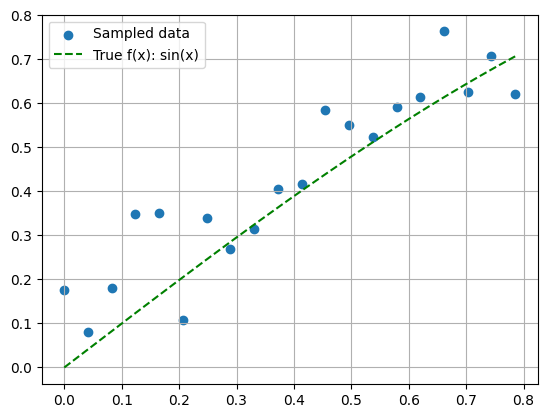

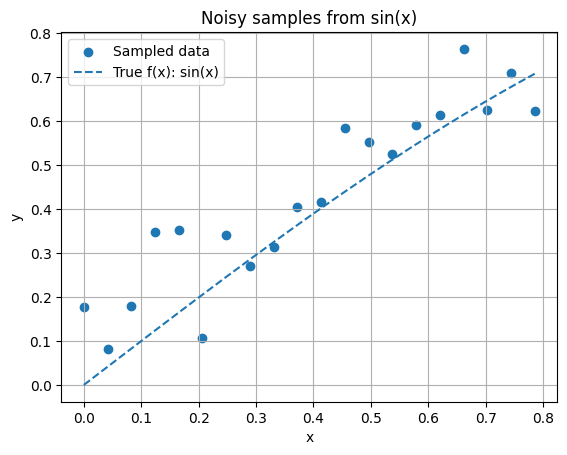

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def generate_sin(x, epsilon):
    noise = np.random.normal(0, epsilon, size=len(x))
    func = np.sin(x) + noise
    return func

n_samples = 20

# create noisy function
x = np.linspace(0, np.pi/4, n_samples)
y = generate_sin(x, 0.1)

# create true function
x_pure = np.linspace(0, np.pi/4, 200)
y_pure = np.sin(x_pure)

# plot data, line
plt.scatter(x, y, label="Sampled data")
plt.plot(x_pure, y_pure, '--', label="True f(x): sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy samples from sin(x)")
plt.grid()
plt.legend()
plt.show()

## Question 2.2 -- Implementation of Linear Regression

Write a function that takes as input a list of $(x,y)$ pairs and returns the coefficients and residuals for a linear regression. Specifically, use the formula for $a$ and $b$ you found in Question 1.1.

*Hint: It may be better to create a new function that computes the sum of squared errors separately, taking $a$, $b$, and the $(x,y)$ pairs as inputs, and outputting a single float value.*

Compute and plot the line of best fit, along with the data and true function as you did above. Also print out the coefficients and the residuals (sum of square errors). How does this line compare to the true function?

---

You should get something similar to this:

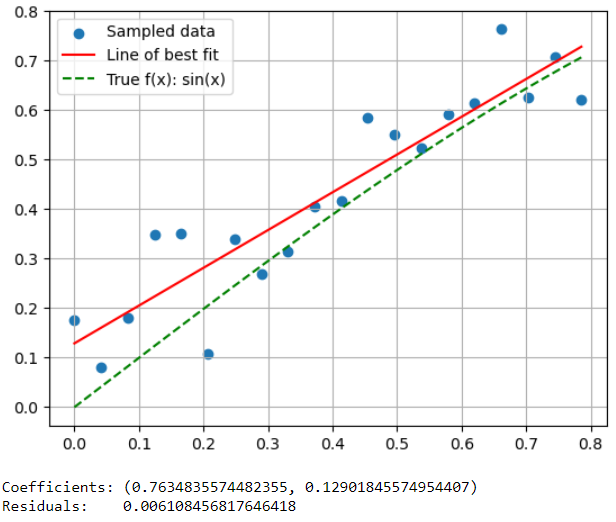

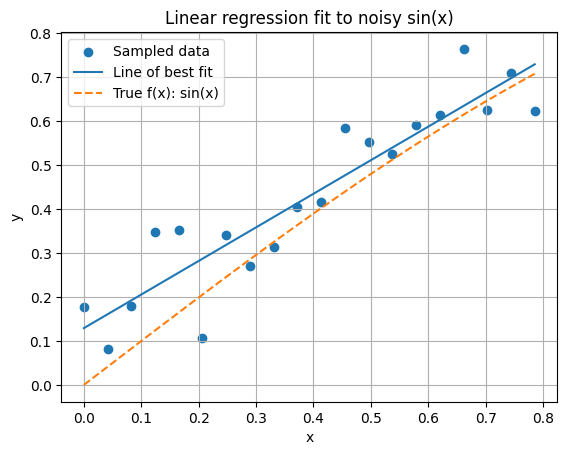

Coefficients: (np.float64(0.12901845574954407), np.float64(0.7634835574482355))
Residuals: 0.12216913635292838


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def generate_sin(x, epsilon):
    noise = np.random.normal(0, epsilon, size=len(x))
    return np.sin(x) + noise

def compute_sos(y_true, y_pred):
    sos = np.sum((y_true - y_pred) ** 2)
    return sos

def lin_reg(xs, ys):
    x_bar = np.mean(xs)
    y_bar = np.mean(ys)

    b = np.sum((xs - x_bar) * (ys - y_bar)) / np.sum((xs - x_bar) ** 2)
    a = y_bar - b * x_bar

    y_pred = a + b * xs
    res = compute_sos(ys, y_pred)

    return a, b, res

n_samples = 20
x = np.linspace(0, np.pi/4, n_samples)
y = generate_sin(x, 0.1)

a, b, res = lin_reg(x, y)
y_best = b * x + a

x_pure = np.linspace(0, np.pi/4, 200)
y_pure = np.sin(x_pure)

plt.scatter(x, y, label="Sampled data")
plt.plot(x, y_best, label="Line of best fit")
plt.plot(x_pure, y_pure, '--', label="True f(x): sin(x)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression fit to noisy sin(x)")
plt.grid()
plt.legend()
plt.show()

print("Coefficients:", (a, b))
print("Residuals:", res)

## Question 2.3 -- Comparison to existing model

Use numpy's `polyfit` functions to get the coefficients and residuals of the same data points. Plot a line using these coefficients, and plot the sampled data, your previous line of best fit, and the true function, as before, for reference. How does this compare to the function you derived for $a$ and $b$? Print out the values for $a$, $b$ and the residuals to compare them. What does this tell you about the way `polyfit` is implemented?

*Tip: Use a dashed/dotted line for the new function to make the comparison easier.*

*General tip: Don't overwrite your previous variables!*

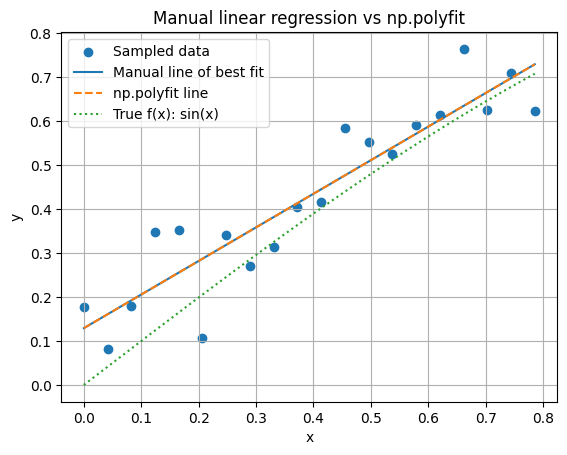

Coefficients: (np.float64(0.12901845574954407), np.float64(0.7634835574482355))
Residuals: 0.12216913635292838
Coefficients (np): (np.float64(0.1290184557495442), np.float64(0.7634835574482354))
Residuals (np): 0.12216913635292836


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def generate_sin(x, epsilon):
    noise = np.random.normal(0, epsilon, size=len(x))
    return np.sin(x) + noise

def compute_sos(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2)

def lin_reg(xs, ys):
    x_bar = np.mean(xs)
    y_bar = np.mean(ys)

    b = np.sum((xs - x_bar) * (ys - y_bar)) / np.sum((xs - x_bar) ** 2)
    a = y_bar - b * x_bar

    y_pred = a + b * xs
    res = compute_sos(ys, y_pred)

    return a, b, res

n_samples = 20
x = np.linspace(0, np.pi/4, n_samples)
y = generate_sin(x, 0.1)

# previous line of best fit
a, b, res = lin_reg(x, y)
y_best = b * x + a

# np.polyfit
b_np, a_np = np.polyfit(x, y, 1)
y_best_np = b_np * x + a_np
res_np = compute_sos(y, y_best_np)

# true function
x_pure = np.linspace(0, np.pi/4, 200)
y_pure = np.sin(x_pure)

# plot everything
plt.scatter(x, y, label="Sampled data")
plt.plot(x, y_best, label="Manual line of best fit")
plt.plot(x, y_best_np, '--', label="np.polyfit line")
plt.plot(x_pure, y_pure, ':', label="True f(x): sin(x)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Manual linear regression vs np.polyfit")
plt.grid()
plt.legend()
plt.show()

# print results
print("Coefficients:", (a, b))
print("Residuals:", res)
print("Coefficients (np):", (a_np, b_np))
print("Residuals (np):", res_np)

The coefficients and residuals from np.polyfit should be the same, or extremely close, to the ones computed manually. This means the plotted line from polyfit will overlap with the previous line of best fit. Any very small difference is due to numerical precision and rounding.

This shows that np.polyfit is implementing the same least-squares idea used in the manual derivation. In other words, it is finding the values of a and b that minimize the sum of squared errors between the observed y-values and the predicted values on the line.

## Question 3 -- Test vs train loss

The mean of the residuals you computed above are often called the *training loss* or *training error* in machine learning lingo. In general, this phrase translates to the loss (difference between observed and predicted $y$ values in whatever metric you wish) over all data points available for you to train on (your *train/train set*). In our case, the 'metric' is the function you minimized, i.e. sum of squared errors.

In real life, you generally do not generate these data points -- you observe them from your experiments. However, you would want for your model to perform well on points that were *not* used to train your model as well -- this is called *generalization*. Thus, to test this, we use a *test set* -- a series of new observations. This will become important in following weeks when we use more complex models.

In general, we would want our test and train sets to have the same distributional properties, including the underlying function and the distribution of noise. Thus, for now, we *generate* a test set and see how our models 'perform' on it (again, we generally do not have access to the underlying function to generate datapoints with, we observe them through experiments). We compute the *test loss* or *test error* using the same metric as the training error (i.e. sum of square errors in this case).

Thus, for this exercise:
- Generate a new set of x-values in the range of $x\in[0,\pi/4]$. Compute a series of y-values using your `generate_sin` function, using the same $\epsilon$ and $n$ as before.
- Rewrite the function that computes the residuals to now compute the *mean* of the residuals. Thus, our loss function is the Mean Squared Error:
$$MSE = \frac{1}{N} \sum_{i=0}^{n}(y_i-\hat{y_i})^2$$
- Make a scatter plot of the train set and test set, and plot the two lines of best fit and the true function computed earlier on the train set. Don't forget labels. Does this seem to be of a similar distribution of the train set?
- Compute and print out the training and test losses.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def generate_sin(x, epsilon):
    noise = np.random.normal(0, epsilon, size=len(x))
    return np.sin(x) + noise

def compute_mse(x_vals, y_true, a, b):
    y_pred = a + b * x_vals
    mse = np.mean((y_true - y_pred) ** 2)
    return mse

def lin_reg(xs, ys):
    x_bar = np.mean(xs)
    y_bar = np.mean(ys)

    b = np.sum((xs - x_bar) * (ys - y_bar)) / np.sum((xs - x_bar) ** 2)
    a = y_bar - b * x_bar

    return a, b

# train set
n_samples = 20
epsilon = 0.1

x = np.linspace(0, np.pi/4, n_samples)
y = generate_sin(x, epsilon)

a, b = lin_reg(x, y)
y_train_pred = a + b * x

# test set
x_test = np.linspace(0, np.pi/4, n_samples)
y_test = generate_sin(x_test, epsilon)
y_test_pred = a + b * x_test

# true function
x_pure = np.linspace(0, np.pi/4, 200)
y_pure = np.sin(x_pure)

# plot
plt.scatter(x, y, label="Train set")
plt.scatter(x_test, y_test, label="Test set")
plt.plot(x, y_train_pred, label="Line of best fit (train)")
plt.plot(x_test, y_test_pred, '--', label="Prediction on test set")
plt.plot(x_pure, y_pure, ':', label="True f(x): sin(x)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train vs test loss")
plt.grid()
plt.legend()
plt.show()

train_loss = compute_mse(x, y, a, b)
test_loss = compute_mse(x_test, y_test, a, b)

print("Coefficients:", (a, b))
print("Train loss:", train_loss)
print("Test loss:", test_loss)

Which of the two losses *should* be better? Which is actually better? Why?

The training loss should usually be better, meaning smaller, because the model was fitted directly on the training set. The test loss is computed on unseen data, so it is a better measure of generalization. In practice, the training loss is often lower than the test loss for this reason.

Here, the two losses should still be fairly close because the train and test sets are generated from the same distribution, using the same function
sin(x) and the same noise level
ϵ=0.1. Any difference between them is caused by random noise in the sampled data.*Add your text answer here*

## Question 4 -- Ablation study of sampling

Try out different values of $n$ and $\epsilon$. How does each one affect the performance of your linear models? (report your steps and general observations both for the train and test sets).


I varied both
n and ϵ and compared the train and test losses.

When
𝑛 increased, the fitted line became more stable and the train and test results became more similar. With small
n, the model depended more on the particular sampled points, so performance was less consistent.

When ϵ increased, both train and test loss increased. Higher noise made the data more scattered, so the linear model fit the data worse.

Overall, largern improved stability, while larger ϵ reduced performance. The training loss was usually slightly lower than the test loss.

## Question 5.1 -- More data

Generate a training and test set using the `generate_sin` function you defined, but in the range $x\in[0,2\pi]$, $n=20$ and $\epsilon=0.2$. Plot the train and test sets (scatter plots) and true function in one plot.

In [ ]:
n_samples = 20
x = np.linspace(0, 2*np.pi, n_samples)
y_train = generate_sin(x, 0.2)
y_test = generate_sin(x, 0.2)

x_pure = np.linspace(0, 2*np.pi, 200)
y_pure = np.sin(x_pure)

plt.scatter(x, y_train, label="Train set")
plt.scatter(x, y_test, label="Test set")
plt.plot(x_pure, y_pure, label="True f(x): sin(x)")
plt.grid()
plt.legend()
plt.show()

## Question 5.2 -- Polynomial fitting

Now, we examine the flexibility of the model we use and the performance on the training and test sets. 'Flexibility' is generally ill-defined, but intuitively, *a learning algorithm $A$ is more flexible than another learning algorithm $B$ if $A$ can fit its computed models $\hat{f}$ more closely to the training data than $B$ can do.* (quote from Jaeger, 2022, pg 11). For example, a quadratic function is more flexible (in theory) than a linear one, since a quadratic function can model data *at least* as well as linear ones. Specifically, the set of all linear functions is a subset of quadratic ones (by setting the quadratic coefficient to zero).

- Using the datapoints you made above with $x\in[0,2\pi]$, compute the best fitting polynomials from degrees $d\in\{1,...,20\}$.
- Save the corresponding train and test losses, and the resulting coefficients. Don't forget to change the function that computes the mean squared errors if required (perhaps `np.polyval` may help here?). Also, don't forget to create your model based _only_ on your train set.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def generate_sin(x, epsilon):
    noise = np.random.normal(0, epsilon, size=len(x))
    return np.sin(x) + noise

def compute_mse_poly(x_vals, y_true, coeffs):
    y_pred = np.polyval(coeffs, x_vals)
    return np.mean((y_true - y_pred) ** 2)

# data from Question 5.1
n_samples = 20
epsilon = 0.2

x = np.linspace(0, 2*np.pi, n_samples)
y_train = generate_sin(x, epsilon)
y_test = generate_sin(x, epsilon)

degrees = range(1, 21)
train_losses = []
test_losses = []
all_coeffs = []

for d in degrees:
    coeffs = np.polyfit(x, y_train, d)
    train_loss = compute_mse_poly(x, y_train, coeffs)
    test_loss = compute_mse_poly(x, y_test, coeffs)

    all_coeffs.append(coeffs)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

# plot train and test loss vs degree
plt.plot(degrees, train_losses, label="Train loss")
plt.plot(degrees, test_losses, label="Test loss")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Polynomial degree vs train/test loss")
plt.grid()
plt.legend()
plt.show()

# print results
for d, tr, te, coeffs in zip(degrees, train_losses, test_losses, all_coeffs):
    print(f"Degree {d}:")
    print("  Train loss:", tr)
    print("  Test loss: ", te)
    print("  Coefficients:", coeffs)

**Bonus**: You may encounter this warning (if you don't, try increasing the range of polynomial degrees):

`RankWarning: Polyfit may be poorly conditioned`

What does this mean?

This warning means the polynomial fit is becoming numerically unstable. Usually this happens for high-degree polynomials, where the data or the powers of
x make the computation poorly scaled. In practice, it means the fitted coefficients may be unreliable even if the code still runs.

## Question 5.3 -- Analysis
Plot the lines of best fit for $d=\{1,2,3,5,10,20\}$. These should look like the plots shown in Lecture 1 under section *Polynomial Regression*. You may also show this in multiple plots as long as you have the reference plots for each (the train and test data and the true underlying function).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def generate_sin(x, epsilon):
    noise = np.random.normal(0, epsilon, size=len(x))
    return np.sin(x) + noise

def compute_mse_poly(x_vals, y_true, coeffs):
    y_pred = np.polyval(coeffs, x_vals)
    return np.mean((y_true - y_pred) ** 2)

# data
n_samples = 20
epsilon = 0.2

x = np.linspace(0, 2*np.pi, n_samples)
y_train = generate_sin(x, epsilon)
y_test = generate_sin(x, epsilon)

x_pure = np.linspace(0, 2*np.pi, 400)
y_pure = np.sin(x_pure)

# fit degrees 1 to 20
degrees = range(1, 21)
train_losses = []
test_losses = []
coeff_dict = {}

for d in degrees:
    coeffs = np.polyfit(x, y_train, d)
    coeff_dict[d] = coeffs
    train_losses.append(compute_mse_poly(x, y_train, coeffs))
    test_losses.append(compute_mse_poly(x, y_test, coeffs))

# plot fits for selected degrees
selected_degrees = [1, 2, 3, 5, 10, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, d in enumerate(selected_degrees):
    coeffs = coeff_dict[d]
    y_fit = np.polyval(coeffs, x_pure)

    axes[i].scatter(x, y_train, label="Train set")
    axes[i].scatter(x, y_test, label="Test set")
    axes[i].plot(x_pure, y_fit, label=f"Degree {d} fit")
    axes[i].plot(x_pure, y_pure, '--', label="True sin(x)")
    axes[i].set_title(f"d = {d}")
    axes[i].grid()

axes[0].legend()
plt.tight_layout()
plt.show()


Now plot the MSE losses versus the flexibility (degree of the best fitting functions) for both the test and train sets. Again, a similar plot can be found in Lecture 1 under *Overfitting and Underfitting*.

In [ ]:
# plot MSE vs flexibility
plt.figure(figsize=(8, 5))
plt.plot(list(degrees), train_losses, label="Train loss")
plt.plot(list(degrees), test_losses, label="Test loss")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Train and test MSE vs model flexibility")
plt.grid()
plt.legend()
plt.show()

## Open Questions (Question 6)
1. Where do the polynomial models start to overfit? How can you tell?
2. What model fits the best to the training data? What model fits the best to the underlying function (visually, according to your intuition about the plots)? Are they the same?
4. Try increasing the number of training points to $n=200$. At what point does overfitting start now?
5. In general, does increasing the number of training points always allow for more flexible models of the real world? Why/why not?

1. The polynomial models start to overfit at the higher degrees, around the point where the training loss keeps decreasing but the test loss starts increasing. You can tell because the fitted curve begins to follow noise in the training data instead of the general shape of the true function.

2. The model that fits the training data best is usually the highest-degree polynomial, because it is the most flexible and can match the training points very closely. Visually, the model that fits the underlying function best is usually a medium-degree polynomial, since it captures the sinusoidal shape without becoming too wiggly. So they are not the same.

3. When I increase the number of training points to (n=200), overfitting starts later, at a higher polynomial degree. This is because with more data, the model has more information about the real pattern and is less likely to fit random noise too early.

4. In general, increasing the number of training points often allows more flexible models to work better, but not always. More data usually helps the model learn the true pattern more reliably, but very flexible models can still overfit, especially if the data is noisy or the model is too complex for the problem.


---

